# Real CA1 Data Exploration

This notebook explores the J16 bandit session CA1 recording data and prepares
it for theta state analysis with the `SwitchingSpikeOscillatorModel`.

## Goals

1. Load and explore the neural recording data
2. Perform data quality checks (position, speed, spike rates)
3. Bin spikes into time series at 250 Hz
4. Select units based on firing rate criteria
5. Create behavioral labels (running vs immobility)
6. Save preprocessed data for subsequent analysis

## Setup

In [1]:
# Enable 64-bit precision for numerical stability
import jax

jax.config.update("jax_enable_x64", True)

In [2]:
# Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add project root to path for imports
# Handle both running from notebooks/ directory and from project root
if Path.cwd().name == "notebooks":
    project_root = Path.cwd().parent
else:
    project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data.load_bandit_data import load_neural_recording_from_files
from state_space_practice.preprocessing import (
    bin_spike_times,
    compute_firing_rates,
    create_behavioral_labels,
    identify_behavioral_bouts,
    interpolate_to_new_times,
    select_units,
)

print(f"JAX version: {jax.__version__}")
print(f"Using device: {jax.devices()[0]}")

JAX version: 0.6.2
Using device: TFRT_CPU_0


## 1. Load Data

In [3]:
# Load the J16 bandit session data
data_path = project_root / "data"
data = load_neural_recording_from_files(data_path, "j1620210710_02_r1")

position_info = data["position_info"]
spike_times = data["spike_times"]
track_graph = data["track_graph"]

print("Data loaded successfully!")
print(f"  Position samples: {len(position_info):,}")
print(f"  Number of units: {len(spike_times)}")
print(f"  Track graph nodes: {track_graph.number_of_nodes()}")
print(f"  Track graph edges: {track_graph.number_of_edges()}")

Data loaded successfully!
  Position samples: 709,321
  Number of units: 203
  Track graph nodes: 10
  Track graph edges: 9


In [4]:
# Basic data summary
print("\nPosition info columns:")
print(position_info.columns.tolist())

print("\nPosition info time range:")
times = position_info.index.values
duration = (times[-1] - times[0])
print(f"  Start: {times[0]:.2f}")
print(f"  End: {times[-1]:.2f}")
print(f"  Duration: {duration:.1f} s ({duration/60:.1f} min)")

# Sampling rate
dt_pos = np.median(np.diff(times))
fs_pos = 1.0 / dt_pos
print(f"  Sampling rate: {fs_pos:.1f} Hz")


Position info columns:
['head_position_x', 'head_position_y', 'head_orientation', 'head_velocity_x', 'head_velocity_y', 'head_speed', 'linear_position', 'track_segment_id', 'projected_x_position', 'projected_y_position', 'patch_id']

Position info time range:
  Start: 1625935757.70
  End: 1625937176.34
  Duration: 1418.6 s (23.6 min)
  Sampling rate: 500.0 Hz


In [5]:
# Spike summary
total_spikes = sum(len(st) for st in spike_times)
print(f"\nSpike data:")
print(f"  Total spikes: {total_spikes:,}")
print(f"  Mean spikes per unit: {total_spikes / len(spike_times):.0f}")

# Spike time range
all_spike_times = np.concatenate([st for st in spike_times if len(st) > 0])
print(f"  Spike time range: [{all_spike_times.min():.2f}, {all_spike_times.max():.2f}]")


Spike data:
  Total spikes: 870,018
  Mean spikes per unit: 4286
  Spike time range: [1625935757.70, 1625937176.34]


## 2. Visualize Position and Speed

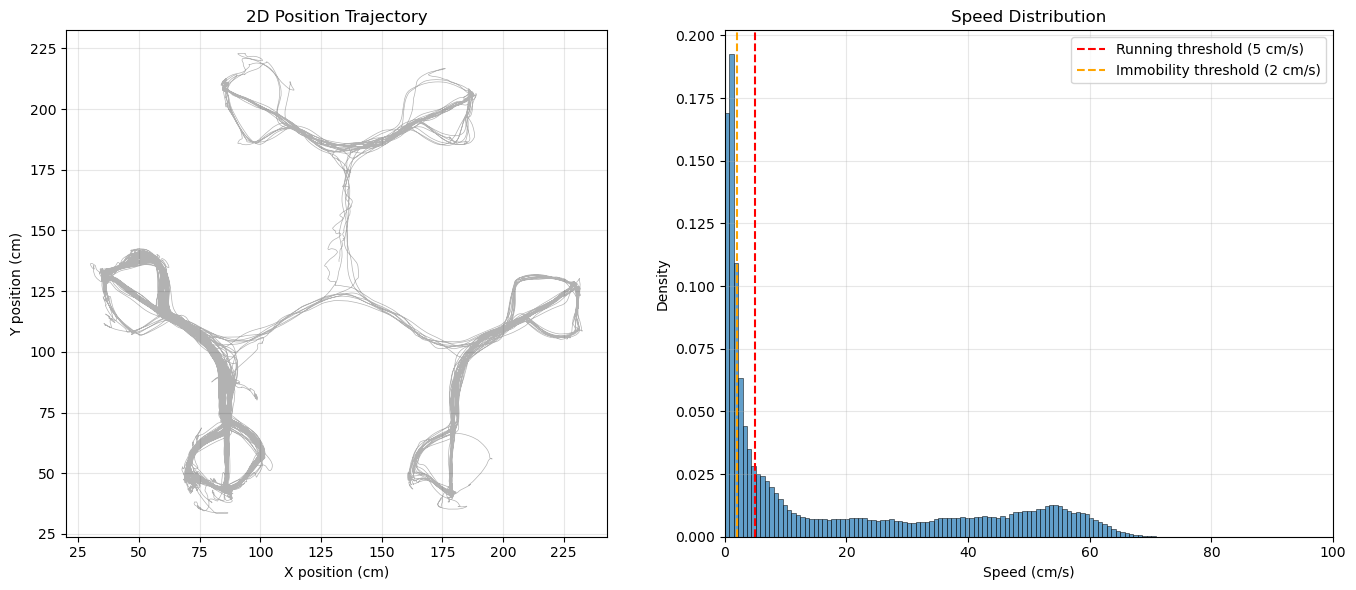

In [6]:
# Plot 2D position trajectory
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2D trajectory
ax = axes[0]
x = position_info["head_position_x"].values
y = position_info["head_position_y"].values
# Subsample for plotting
subsample = 10
ax.plot(x[::subsample], y[::subsample], "k-", alpha=0.3, linewidth=0.5)
ax.set_xlabel("X position (cm)")
ax.set_ylabel("Y position (cm)")
ax.set_title("2D Position Trajectory")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# Speed distribution
ax = axes[1]
speed = position_info["head_speed"].values
ax.hist(speed, bins=100, density=True, alpha=0.7, edgecolor="black", linewidth=0.5)
ax.axvline(5, color="red", linestyle="--", label="Running threshold (5 cm/s)")
ax.axvline(2, color="orange", linestyle="--", label="Immobility threshold (2 cm/s)")
ax.set_xlabel("Speed (cm/s)")
ax.set_ylabel("Density")
ax.set_title("Speed Distribution")
ax.set_xlim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ca1_position_speed.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Speed statistics
print("Speed statistics:")
print(f"  Mean: {np.mean(speed):.1f} cm/s")
print(f"  Median: {np.median(speed):.1f} cm/s")
print(f"  Std: {np.std(speed):.1f} cm/s")
print(f"  Max: {np.max(speed):.1f} cm/s")
print(f"  % time running (>5 cm/s): {100 * np.mean(speed > 5):.1f}%")
print(f"  % time immobile (<2 cm/s): {100 * np.mean(speed < 2):.1f}%")

Speed statistics:
  Mean: 18.3 cm/s
  Median: 6.4 cm/s
  Std: 20.8 cm/s
  Max: 73.0 cm/s
  % time running (>5 cm/s): 53.5%
  % time immobile (<2 cm/s): 32.6%


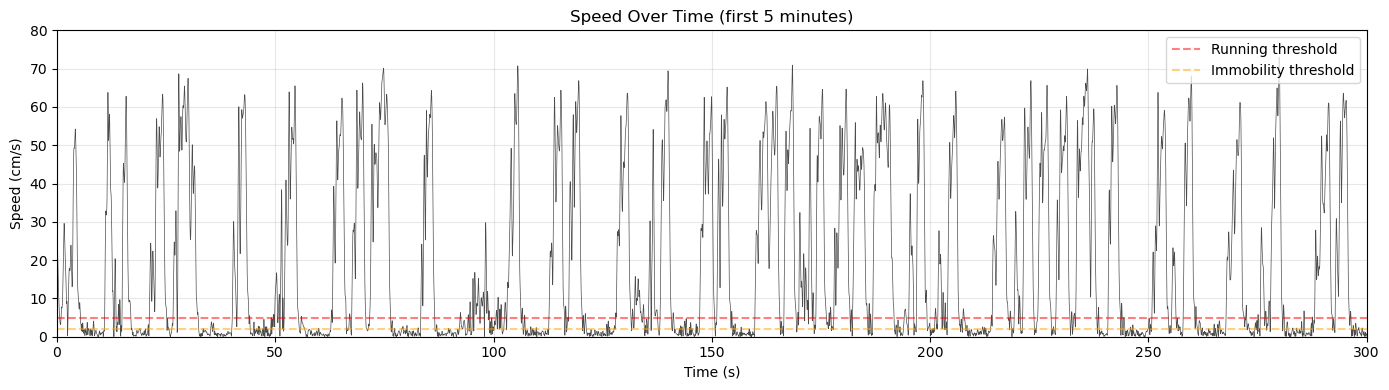

In [8]:
# Plot speed over time
fig, ax = plt.subplots(figsize=(14, 4))

# Plot first 5 minutes
time_window = 5 * 60  # 5 minutes
t_rel = times - times[0]
mask = t_rel < time_window

ax.plot(t_rel[mask], speed[mask], "k-", alpha=0.7, linewidth=0.5)
ax.axhline(5, color="red", linestyle="--", alpha=0.5, label="Running threshold")
ax.axhline(2, color="orange", linestyle="--", alpha=0.5, label="Immobility threshold")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (cm/s)")
ax.set_title("Speed Over Time (first 5 minutes)")
ax.set_xlim(0, time_window)
ax.set_ylim(0, 80)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ca1_speed_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Firing Rate Analysis

In [9]:
# Compute firing rates for all units
firing_rates = compute_firing_rates(spike_times)

print("Firing rate statistics:")
print(f"  Mean: {np.mean(firing_rates):.2f} Hz")
print(f"  Median: {np.median(firing_rates):.2f} Hz")
print(f"  Std: {np.std(firing_rates):.2f} Hz")
print(f"  Min: {np.min(firing_rates):.2f} Hz")
print(f"  Max: {np.max(firing_rates):.2f} Hz")

Firing rate statistics:
  Mean: 3.02 Hz
  Median: 0.08 Hz
  Std: 7.91 Hz
  Min: 0.00 Hz
  Max: 44.82 Hz


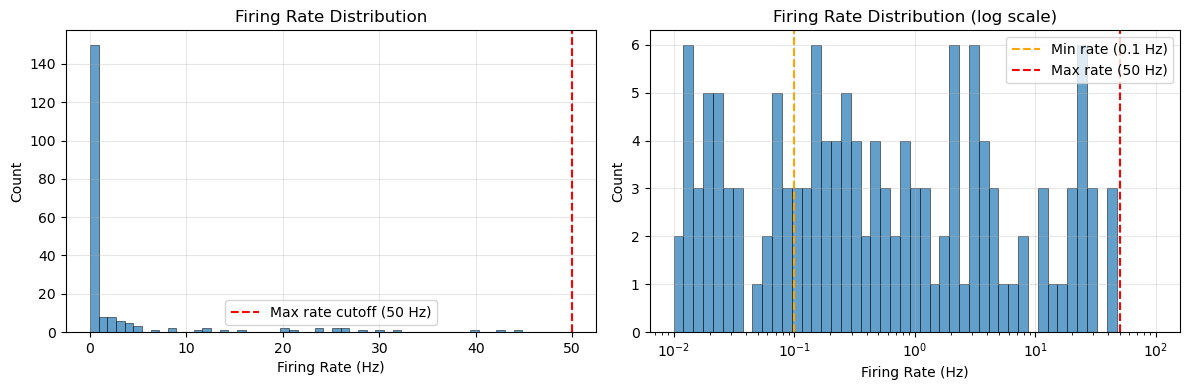

In [10]:
# Plot firing rate distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
ax = axes[0]
ax.hist(firing_rates, bins=50, alpha=0.7, edgecolor="black", linewidth=0.5)
ax.axvline(50, color="red", linestyle="--", label="Max rate cutoff (50 Hz)")
ax.set_xlabel("Firing Rate (Hz)")
ax.set_ylabel("Count")
ax.set_title("Firing Rate Distribution")
ax.legend()
ax.grid(True, alpha=0.3)

# Log scale (to see low-rate place cells)
ax = axes[1]
ax.hist(firing_rates, bins=np.logspace(-2, 2, 50), alpha=0.7, edgecolor="black", linewidth=0.5)
ax.axvline(0.1, color="orange", linestyle="--", label="Min rate (0.1 Hz)")
ax.axvline(50, color="red", linestyle="--", label="Max rate (50 Hz)")
ax.set_xscale("log")
ax.set_xlabel("Firing Rate (Hz)")
ax.set_ylabel("Count")
ax.set_title("Firing Rate Distribution (log scale)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ca1_firing_rates.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Select units based on firing rate criteria
# Include units with at least some spikes (>0.05 Hz) but exclude likely MUA (>50 Hz)
selected_indices = select_units(spike_times, min_rate=0.05, max_rate=50.0)

print(f"\nUnit selection:")
print(f"  Total units: {len(spike_times)}")
print(f"  Selected units: {len(selected_indices)}")
print(f"  Excluded (low rate <0.05 Hz): {np.sum(firing_rates < 0.05)}")
print(f"  Excluded (high rate >50 Hz): {np.sum(firing_rates > 50)}")

selected_spike_times = [spike_times[i] for i in selected_indices]
selected_firing_rates = firing_rates[selected_indices]

print(f"\nSelected unit statistics:")
print(f"  Mean rate: {np.mean(selected_firing_rates):.2f} Hz")
print(f"  Median rate: {np.median(selected_firing_rates):.2f} Hz")


Unit selection:
  Total units: 203
  Selected units: 107
  Excluded (low rate <0.05 Hz): 96
  Excluded (high rate >50 Hz): 0

Selected unit statistics:
  Mean rate: 5.72 Hz
  Median rate: 0.85 Hz


## 4. Spike Raster Visualization

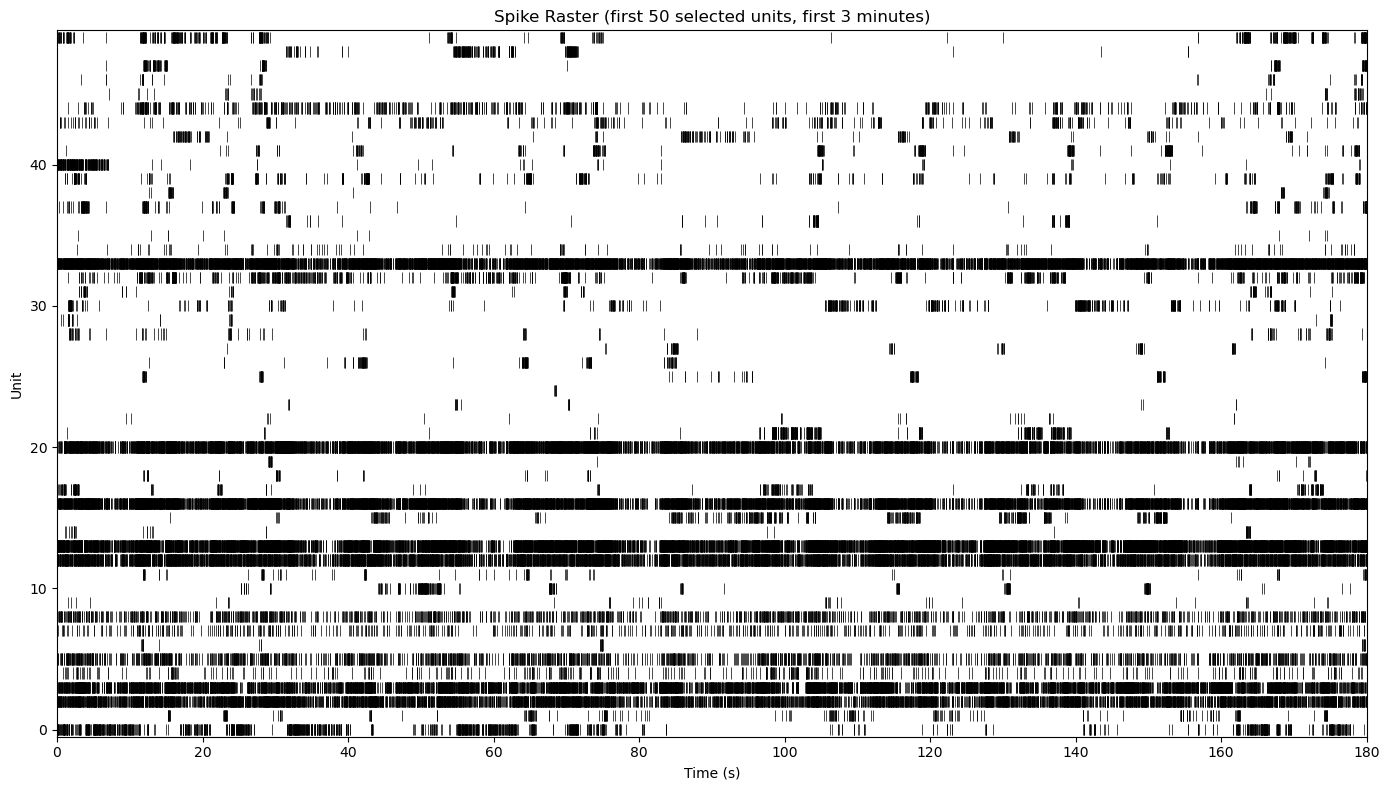

In [12]:
# Plot spike raster for subset of neurons
fig, ax = plt.subplots(figsize=(14, 8))

# Show first 3 minutes
t_start = times[0]
t_end = t_start + 3 * 60

# Show first 50 selected units
n_show = min(50, len(selected_spike_times))

for i in range(n_show):
    st = selected_spike_times[i]
    st_window = st[(st >= t_start) & (st <= t_end)]
    ax.eventplot(
        [st_window - t_start],
        lineoffsets=i,
        linelengths=0.8,
        colors="black",
        linewidths=0.5,
    )

ax.set_xlabel("Time (s)")
ax.set_ylabel("Unit")
ax.set_title(f"Spike Raster (first {n_show} selected units, first 3 minutes)")
ax.set_xlim(0, 3 * 60)
ax.set_ylim(-0.5, n_show - 0.5)

plt.tight_layout()
plt.savefig("ca1_spike_raster.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Bin Spikes at 250 Hz

In [13]:
# Create time bins at 250 Hz (4 ms bins)
sampling_freq = 250.0
dt = 1.0 / sampling_freq

# Use position time range
t_start = times[0]
t_end = times[-1]

time_bins = np.arange(t_start, t_end, dt)
n_time = len(time_bins)

print(f"Binning parameters:")
print(f"  Sampling frequency: {sampling_freq} Hz")
print(f"  Bin width: {dt * 1000:.1f} ms")
print(f"  Number of time bins: {n_time:,}")
print(f"  Duration: {n_time * dt:.1f} s ({n_time * dt / 60:.1f} min)")

Binning parameters:
  Sampling frequency: 250.0 Hz
  Bin width: 4.0 ms
  Number of time bins: 354,660
  Duration: 1418.6 s (23.6 min)


In [14]:
# Bin spikes
print("\nBinning spikes...")
binned_spikes = bin_spike_times(selected_spike_times, time_bins)
print(f"  Binned spikes shape: {binned_spikes.shape}")
print(f"  Total spike count (binned): {binned_spikes.sum():,}")
print(f"  Max spikes per bin: {binned_spikes.max()}")
print(f"  Mean spikes per bin per neuron: {binned_spikes.mean():.4f}")


Binning spikes...
  Binned spikes shape: (354660, 107)
  Total spike count (binned): 868,966
  Max spikes per bin: 3
  Mean spikes per bin per neuron: 0.0229


In [15]:
# Verify binning preserves spike counts
total_original = sum(
    np.sum((st >= t_start) & (st < t_end)) for st in selected_spike_times
)
total_binned = binned_spikes.sum()
print(f"\nSpike count verification:")
print(f"  Original (in window): {total_original:,}")
print(f"  Binned: {total_binned:,}")
print(f"  Match: {total_original == total_binned}")


Spike count verification:
  Original (in window): 868,967
  Binned: 868,966
  Match: False


## 6. Interpolate Speed to Spike Bins

In [16]:
# Interpolate speed to new time bins
speed_interp = interpolate_to_new_times(
    values=speed,
    original_times=times,
    new_times=time_bins,
    kind="linear",
)

print(f"Speed interpolation:")
print(f"  Original samples: {len(speed):,}")
print(f"  Interpolated samples: {len(speed_interp):,}")
print(f"  Speed range: [{speed_interp.min():.1f}, {speed_interp.max():.1f}] cm/s")

Speed interpolation:
  Original samples: 709,321
  Interpolated samples: 354,660
  Speed range: [0.0, 73.0] cm/s


## 7. Create Behavioral Labels

In [17]:
# Create behavioral labels
behavioral_labels = create_behavioral_labels(
    speed_interp,
    running_threshold=5.0,
    immobility_threshold=2.0,
)

print("Behavioral label distribution:")
print(f"  Immobility (0): {100 * np.mean(behavioral_labels == 0):.1f}%")
print(f"  Running (1): {100 * np.mean(behavioral_labels == 1):.1f}%")
print(f"  Transition (2): {100 * np.mean(behavioral_labels == 2):.1f}%")

Behavioral label distribution:
  Immobility (0): 32.6%
  Running (1): 53.4%
  Transition (2): 13.9%


In [18]:
# Identify running and immobility bouts
# Minimum bout duration: 2 seconds = 500 samples at 250 Hz
min_bout_samples = int(2.0 * sampling_freq)

running_bouts = identify_behavioral_bouts(
    speed_interp,
    speed_threshold=5.0,
    min_duration=min_bout_samples,
    above_threshold=True,
)

immobility_bouts = identify_behavioral_bouts(
    speed_interp,
    speed_threshold=2.0,
    min_duration=min_bout_samples,
    above_threshold=False,
)

print(f"\nBehavioral bouts (min duration = {min_bout_samples / sampling_freq:.1f} s):")
print(f"  Running bouts: {len(running_bouts)}")
print(f"  Immobility bouts: {len(immobility_bouts)}")

if len(running_bouts) > 0:
    running_durations = [(e - s) / sampling_freq for s, e in running_bouts]
    print(f"  Running bout durations: {np.mean(running_durations):.1f} ± {np.std(running_durations):.1f} s")

if len(immobility_bouts) > 0:
    immobility_durations = [(e - s) / sampling_freq for s, e in immobility_bouts]
    print(f"  Immobility bout durations: {np.mean(immobility_durations):.1f} ± {np.std(immobility_durations):.1f} s")


Behavioral bouts (min duration = 2.0 s):
  Running bouts: 185
  Immobility bouts: 57
  Running bout durations: 3.4 ± 0.6 s
  Immobility bout durations: 3.1 ± 0.8 s


## 8. Visualize Preprocessed Data

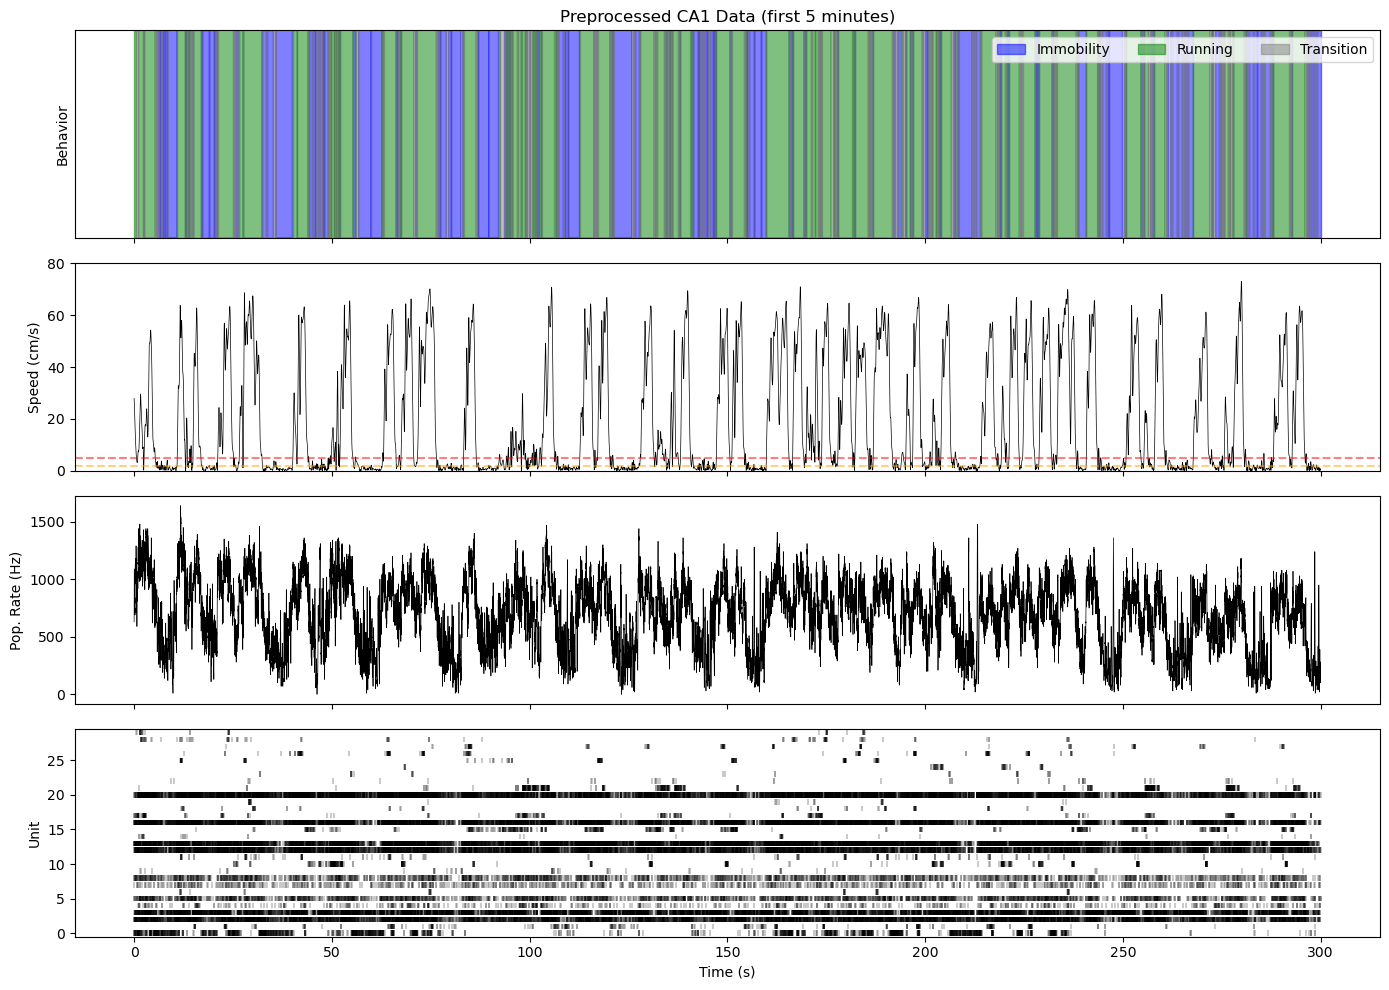

In [19]:
# Plot overview of preprocessed data
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Time axis (relative to start)
t_rel_bins = time_bins - time_bins[0]

# Show first 5 minutes
plot_duration = 5 * 60
plot_mask = t_rel_bins < plot_duration

# Panel 1: Behavioral labels
ax = axes[0]
colors = ["blue", "green", "gray"]
labels_text = ["Immobility", "Running", "Transition"]
for label in [0, 1, 2]:
    mask = (behavioral_labels == label) & plot_mask
    ax.fill_between(
        t_rel_bins,
        0,
        1,
        where=mask,
        alpha=0.5,
        color=colors[label],
        label=labels_text[label],
    )
ax.set_ylabel("Behavior")
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.legend(loc="upper right", ncol=3)
ax.set_title("Preprocessed CA1 Data (first 5 minutes)")

# Panel 2: Speed
ax = axes[1]
ax.plot(t_rel_bins[plot_mask], speed_interp[plot_mask], "k-", linewidth=0.5)
ax.axhline(5, color="red", linestyle="--", alpha=0.5)
ax.axhline(2, color="orange", linestyle="--", alpha=0.5)
ax.set_ylabel("Speed (cm/s)")
ax.set_ylim(0, 80)

# Panel 3: Population spike rate
ax = axes[2]
# Compute population rate (sum across neurons, smooth with 100 ms window)
pop_rate = binned_spikes.sum(axis=1) / dt  # spikes per second
window = int(0.1 * sampling_freq)  # 100 ms
pop_rate_smooth = np.convolve(pop_rate, np.ones(window) / window, mode="same")
ax.plot(t_rel_bins[plot_mask], pop_rate_smooth[plot_mask], "k-", linewidth=0.5)
ax.set_ylabel("Pop. Rate (Hz)")

# Panel 4: Spike raster (subset of neurons)
ax = axes[3]
n_show = min(30, binned_spikes.shape[1])
for i in range(n_show):
    spike_times_i = t_rel_bins[binned_spikes[:, i] > 0]
    spike_times_i = spike_times_i[spike_times_i < plot_duration]
    ax.eventplot(
        [spike_times_i],
        lineoffsets=i,
        linelengths=0.8,
        colors="black",
        linewidths=0.3,
    )
ax.set_ylabel("Unit")
ax.set_xlabel("Time (s)")
ax.set_ylim(-0.5, n_show - 0.5)

plt.tight_layout()
plt.savefig("ca1_preprocessed_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Save Preprocessed Data

In [20]:
# Save preprocessed data for use in subsequent notebooks
import pickle

output_path = data_path / "ca1_preprocessed_250Hz.pkl"

preprocessed_data = {
    "binned_spikes": binned_spikes,
    "time_bins": time_bins,
    "speed": speed_interp,
    "behavioral_labels": behavioral_labels,
    "selected_unit_indices": selected_indices,
    "sampling_freq": sampling_freq,
    "dt": dt,
    "running_bouts": running_bouts,
    "immobility_bouts": immobility_bouts,
    "n_neurons": binned_spikes.shape[1],
    "n_time": binned_spikes.shape[0],
}

with open(output_path, "wb") as f:
    pickle.dump(preprocessed_data, f)

print(f"Preprocessed data saved to: {output_path}")
print(f"  File size: {output_path.stat().st_size / 1e6:.1f} MB")

Preprocessed data saved to: /Users/edeno/Documents/GitHub/state_space_practice/data/ca1_preprocessed_250Hz.pkl
  File size: 312.1 MB


## 10. Summary

In [21]:
print("=" * 60)
print("Data Exploration Summary")
print("=" * 60)
print(f"\nOriginal data:")
print(f"  Recording duration: {duration:.1f} s ({duration/60:.1f} min)")
print(f"  Total units: {len(spike_times)}")
print(f"  Total spikes: {total_spikes:,}")

print(f"\nPreprocessed data:")
print(f"  Sampling frequency: {sampling_freq} Hz")
print(f"  Bin width: {dt * 1000:.1f} ms")
print(f"  Selected units: {len(selected_indices)}")
print(f"  Time bins: {n_time:,}")
print(f"  Binned spikes shape: {binned_spikes.shape}")

print(f"\nBehavioral breakdown:")
print(f"  Immobility: {100 * np.mean(behavioral_labels == 0):.1f}%")
print(f"  Running: {100 * np.mean(behavioral_labels == 1):.1f}%")
print(f"  Transition: {100 * np.mean(behavioral_labels == 2):.1f}%")

print(f"\nRunning bouts (>2s): {len(running_bouts)}")
print(f"Immobility bouts (>2s): {len(immobility_bouts)}")
print("=" * 60)

Data Exploration Summary

Original data:
  Recording duration: 1418.6 s (23.6 min)
  Total units: 203
  Total spikes: 870,018

Preprocessed data:
  Sampling frequency: 250.0 Hz
  Bin width: 4.0 ms
  Selected units: 107
  Time bins: 354,660
  Binned spikes shape: (354660, 107)

Behavioral breakdown:
  Immobility: 32.6%
  Running: 53.4%
  Transition: 13.9%

Running bouts (>2s): 185
Immobility bouts (>2s): 57


## Next Steps

The preprocessed data is now ready for theta state analysis.
Proceed to `real_ca1_theta_segmentation.py` to:

1. Fit the `SwitchingSpikeOscillatorModel`
2. Extract inferred theta states
3. Validate against behavioral correlates